In [1]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 95.9 MB/s eta 0:00:00


Create a file named download_nltk.py.

In [2]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [5]:
%%writefile download_nltk.py
import nltk
nltk.download("stopwords")
nltk.download("punkt")

Writing download_nltk.py


Run it once:

In [4]:
!python download_nltk.py

python3: can't open file '/content/download_nltk.py': [Errno 2] No such file or directory


Create preprocess.py.

In [8]:
import re
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

def clean_resume(text):
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"RT|cc", " ", text)
    text = re.sub(r"#\S+", " ", text)
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)

    words = text.lower().split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [10]:
import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_resume(text):
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"RT|cc", " ", text)
    text = re.sub(r"#\S+", " ", text)
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)

    words = text.lower().split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

sample = """
John Doe
Python Developer
Email: john@gmail.com

Experienced in Machine Learning,
Data Science,
Deep Learning,
TensorFlow,
SQL,
Python.
"""

print(clean_resume(sample))

john doe python developer email john experienced machine learning data science deep learning tensorflow sql python


Step 9: train.py

In [14]:
import pandas as pd
import joblib
import os

import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_resume(text):
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"RT|cc", " ", text)
    text = re.sub(r"#\S+", " ", text)
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)

    words = text.lower().split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load dataset
df = pd.read_csv("/content/Resume.csv")

# Clean resume text
df["clean_resume"] = df["Resume_str"].apply(clean_resume)

# Encode labels
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["Category"])

# TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_resume"])
y = df["label"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Train model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, pred)

print("=" * 50)
print("Accuracy:", acc)
print("=" * 50)

# Classification Report
print(classification_report(y_test, pred))

# Confusion Matrix
cm = confusion_matrix(y_test, pred)

print(cm)

# Create the 'model/' directory if it doesn't exist
os.makedirs("model", exist_ok=True)

# Save everything
joblib.dump(model, "model/classifier.pkl")
joblib.dump(vectorizer, "model/vectorizer.pkl")
joblib.dump(encoder, "model/encoder.pkl")

print("\nModel Saved Successfully.")

Accuracy: 0.6519114688128773
              precision    recall  f1-score   support

           0       0.65      0.83      0.73        24
           1       0.35      0.54      0.43        24
           2       1.00      0.46      0.63        13
           3       0.67      0.21      0.32        19
           4       0.46      0.29      0.35        21
           5       0.00      0.00      0.00         7
           6       0.86      0.75      0.80        24
           7       0.83      0.65      0.73        23
           8       0.00      0.00      0.00         4
           9       0.46      0.79      0.58        24
          10       0.81      0.71      0.76        24
          11       0.82      0.82      0.82        22
          12       0.44      0.17      0.25        23
          13       0.84      0.76      0.80        21
          14       0.71      0.53      0.61        19
          15       0.72      0.75      0.73        24
          16       0.81      0.71      0.76        2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Step 12: Create predict.py

In [16]:
import joblib
import re
import nltk
from nltk.corpus import stopwords

# Define stop_words and clean_resume function locally
stop_words = set(stopwords.words("english"))

def clean_resume(text):
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"RT|cc", " ", text)
    text = re.sub(r"#\S+", " ", text)
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)

    words = text.lower().split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Load saved files
model = joblib.load("model/classifier.pkl")
vectorizer = joblib.load("model/vectorizer.pkl")
encoder = joblib.load("model/encoder.pkl")

resume = """
Python Developer

Machine Learning
Deep Learning
TensorFlow
SQL
Pandas
Scikit-learn
Data Analysis
"""

resume = clean_resume(resume)

features = vectorizer.transform([resume])

prediction = model.predict(features)

category = encoder.inverse_transform(prediction)

print("Predicted Category:", category[0])

Predicted Category: CONSULTANT


Step 13: Generate Evaluation Visualizations

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


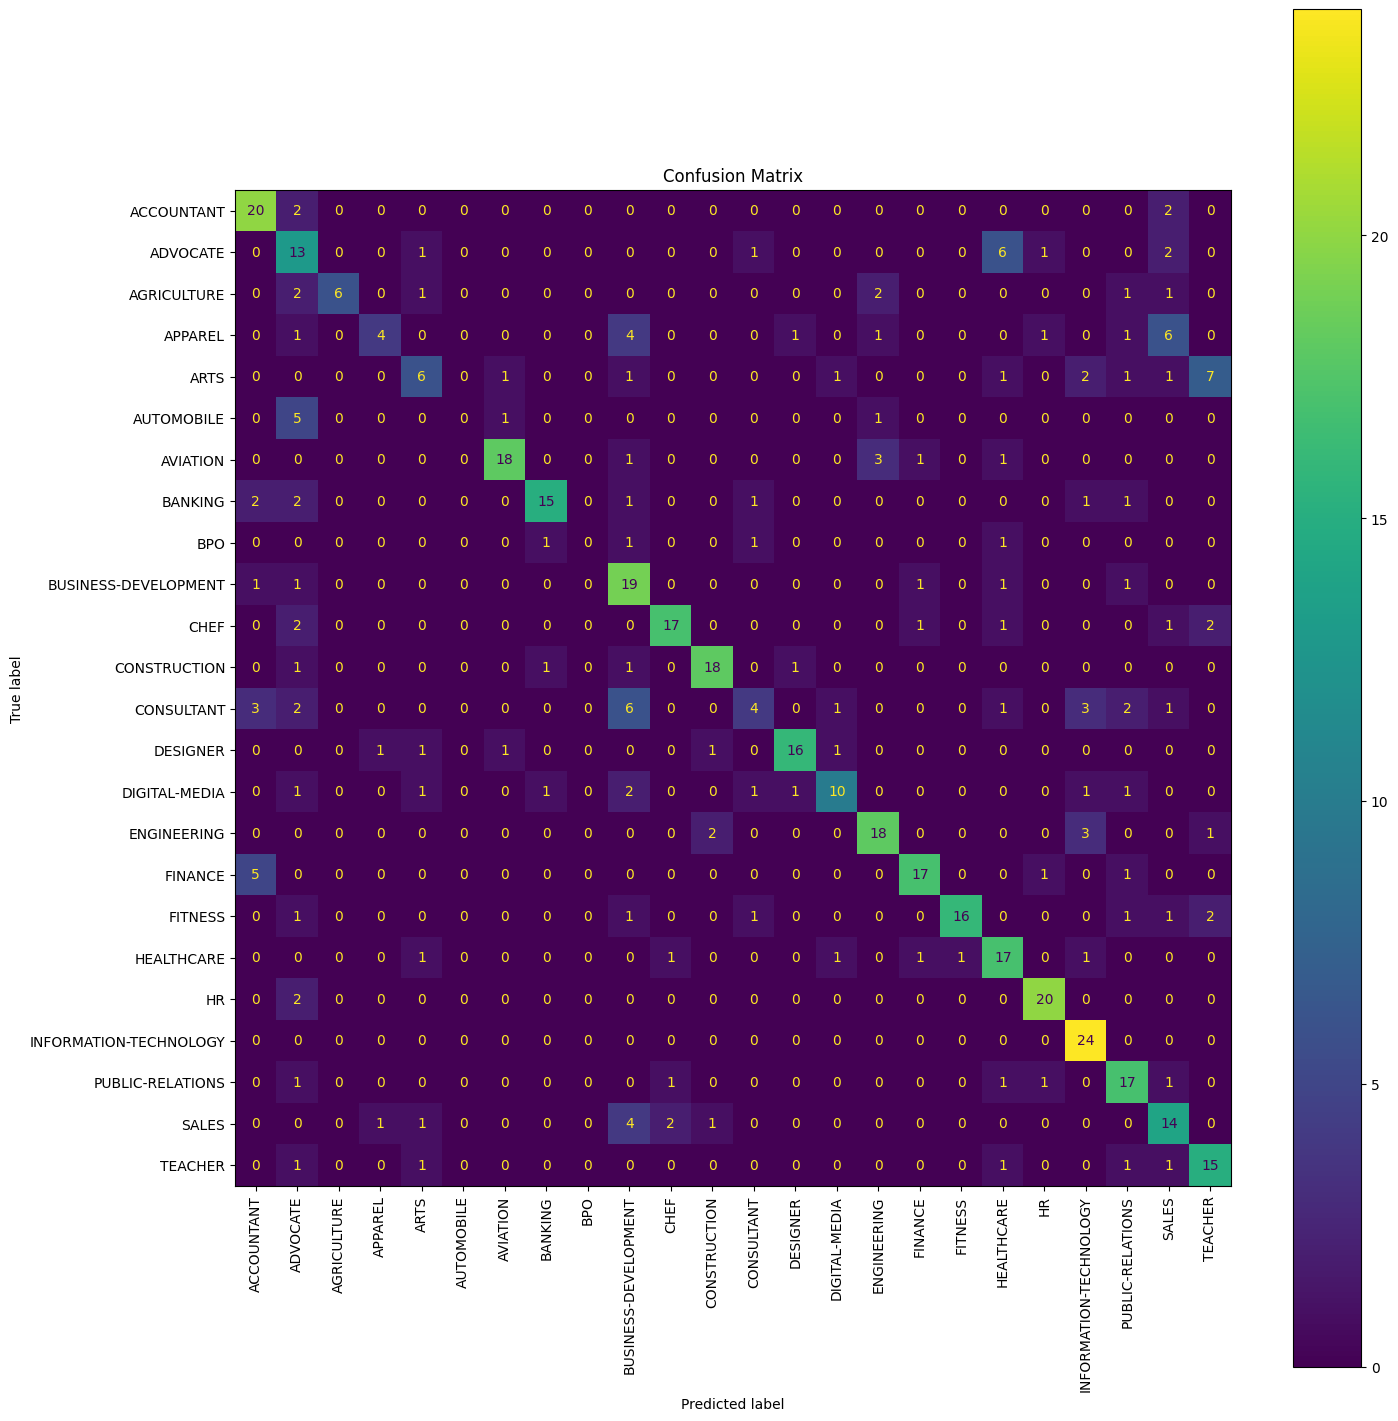

In [17]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

import re
import nltk
from nltk.corpus import stopwords

# Define stop_words and clean_resume function locally
stop_words = set(stopwords.words("english"))

def clean_resume(text):
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"RT|cc", " ", text)
    text = re.sub(r"#\S+", " ", text)
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)

    words = text.lower().split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("/content/Resume.csv")

df["clean_resume"] = df["Resume_str"].apply(clean_resume)

vectorizer = joblib.load("model/vectorizer.pkl")
encoder = joblib.load("model/encoder.pkl")
model = joblib.load("model/classifier.pkl")

X = vectorizer.transform(df["clean_resume"])
y = encoder.transform(df["Category"])

_, X_test, _, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

pred = model.predict(X_test)

# Create the 'results/' directory if it doesn't exist
os.makedirs("results", exist_ok=True)

# Save classification report
with open("results/classification_report.txt", "w") as f:
    f.write(classification_report(y_test, pred))

# Generate and save Confusion Matrix plot
cm = confusion_matrix(y_test, pred, labels=encoder.transform(encoder.classes_))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(cmap='viridis', ax=ax)
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("results/confusion_matrix.png")
plt.show()

In [18]:
# Save confusion matrix image
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("results/confusion_matrix.png", dpi=300)
plt.close()

print("Evaluation files generated successfully.")


Evaluation files generated successfully.


Step 14: app.py

In [21]:
%%writefile app.py
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords

# Define stop_words and clean_resume function locally
stop_words = set(stopwords.words("english"))

def clean_resume(text):
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"RT|cc", " ", text)
    text = re.sub(r"#\S+", " ", text)
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)

    words = text.lower().split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# ----------------------------
# Load Saved Model
# ----------------------------
model = joblib.load("model/classifier.pkl")
vectorizer = joblib.load("model/vectorizer.pkl")
encoder = joblib.load("model/encoder.pkl")

# ----------------------------
# Page Configuration
# ----------------------------
st.set_page_config(
    page_title="AI Resume Screening",
    page_icon="📄",
    layout="centered",
)

st.title("📄 AI Resume Screening & Job Recommendation System")
st.write(
    "Paste the text of a resume below to classify it into the most likely job category."
)

# ----------------------------
# Input Area
# ----------------------------
resume_text = st.text_area(
    "Resume Text",
    height=300,
    placeholder="Paste the complete resume here...",
)

# ----------------------------
# Prediction
# ----------------------------
if st.button("Predict Category"):
    if resume_text.strip() == "":
        st.warning("Please enter resume text.")
    else:
        cleaned = clean_resume(resume_text)

        features = vectorizer.transform([cleaned])

        prediction = model.predict(features)

        category = encoder.inverse_transform(prediction)[0]

        st.success(f"Predicted Category: **{category}**")

Writing app.py


In [ ]:
!pip install -q localtunnel
!streamlit run app.py &>/content/logs.txt & \
  npx localtunnel --port 8501 & curl ipv4.icanhazip.com

ERROR: Could not find a version that satisfies the requirement localtunnel (from versions: none)
ERROR: No matching distribution found for localtunnel
35.185.73.89
⠙⠹⠸⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 